# Marketplace Orders Dataset

This notebook explores the **Olist Brazilian E-Commerce** dataset: a real online marketplace where many
sellers list products and customers place orders. Unlike a single flat spreadsheet, this data is
**relational** — it lives in 9 separate CSV files linked by shared ID columns (keys). To answer any
real business question we must **join** the right tables together.

**Dataset columns overview**

| File | One row = | Primary key |
|---|---|---|
| orders.csv | one order | order_id |
| order_items.csv | one item line in an order | order_id + order_item_id |
| order_payments.csv | one payment transaction | order_id + payment_sequential |
| order_reviews.csv | one review | review_id |
| customers.csv | one customer (per order) | customer_id |
| products.csv | one product | product_id |
| sellers.csv | one seller | seller_id |
| geolocation.csv | one zip-code location point | geolocation_zip_code_prefix (not unique) |
| category_translation.csv | one category translation | product_category_name |

- **Scale:** ~100k orders, ~113k order items, ~33k products, ~3k sellers
- **Time span:** 2016 – 2018


## Questions we want to answer

Before any analysis it is good practice to write down the questions we are trying to answer.
This keeps the exploration focused instead of random. I want to answer:

1. **Does the geographic distance between customer and seller affect delivery delay and customer satisfaction?**
2. **Which sellers have poor performance, what percentage of total sellers do they represent, and how does their performance relate to revenue?**
3. **Do product characteristics (weight, name length, description length, number of photos) affect sales and shipping cost?**
4. **Who are the repeat buyers, and what is their purchasing behavior (payment method + product type)?**


The rest of the notebook answers these questions step by step.


## 0. Setup

First we import the libraries we need:

- **pandas** (`pd`): the main library for working with tables (**DataFrames**).
- **numpy** (`np`): fast numeric operations; we use it for the distance formula.
- **matplotlib.pyplot** (`plt`): the plotting library.

In [6]:
# Core libraries for data analysis and plotting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



## 1. Loading the data

The dataset is split across 9 CSV files. `pd.read_csv(...)` reads each one into its own DataFrame.
All paths below are **relative** to this notebook — put the 9 CSV files in a folder called `marketplace_data/`
next to this notebook (or change `PATH` below).


In [55]:
PATH = 'marketplace_data/'
PATH = r'C:\Users\hp\Downloads\marketplace_orders\\'

orders = pd.read_csv(PATH + 'orders.csv')
order_items = pd.read_csv(PATH + 'order_items.csv')
order_payments = pd.read_csv(PATH + 'order_payments.csv')
order_reviews = pd.read_csv(PATH + 'order_reviews.csv')
customers = pd.read_csv(PATH + 'customers.csv')
products = pd.read_csv(PATH + 'products.csv')
sellers = pd.read_csv(PATH + 'sellers.csv')
geolocation = pd.read_csv(PATH + 'geolocation.csv')
category_translation = pd.read_csv(PATH + 'category_translation.csv')

orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [ ]:
# A quick row count for every table, to check it matches what we expect
tables = {
    'orders': orders, 'order_items': order_items, 'order_payments': order_payments,
    'order_reviews': order_reviews, 'customers': customers, 'products': products,
    'sellers': sellers, 'geolocation': geolocation, 'category_translation': category_translation
}
for name, table in tables.items():
    rows = table.shape[0]
    columns = table.shape[1]
    print(name, "->", rows, "rows,", columns, "columns")


orders                 ->    99,441 rows, 8 columns
order_items            ->   112,650 rows, 7 columns
order_payments         ->   103,886 rows, 5 columns
order_reviews          ->    99,224 rows, 7 columns
customers              ->    99,441 rows, 5 columns
products               ->    32,951 rows, 9 columns
sellers                ->     3,095 rows, 4 columns
geolocation            -> 1,000,163 rows, 5 columns
category_translation   ->        71 rows, 2 columns


## 2. Quick exploration

Before doing anything fancy, we ask the data some basic questions: what columns exist, what types are
they, and where are the missing values. We focus on the tables that matter most for our 4 questions:
`orders`, `order_items`, `order_reviews`, `products`, and `customers`.


In [57]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


In [58]:
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  str    
 1   product_category_name       32341 non-null  str    
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), str(2)
memory usage: 2.3 MB


In [79]:
# Missing values as a percentage of rows, for the columns we will actually use later.
# Several date columns contain nulls -> these belong to orders that were cancelled or never delivered.
for col in cols_to_check:
    missing = orders[col].isna().mean() * 100
    print(col, ":", round(missing, 2), "%")

order_delivered_customer_date : 2.98 %
order_estimated_delivery_date : 0.0 %
order_approved_at : 0.16 %


In [80]:
# products.csv is also missing a few rows of weight/description info -> we will drop those when needed.
(products.isna().mean() * 100).round(2)

product_id                    0.00
product_category_name         1.85
product_name_lenght           1.85
product_description_lenght    1.85
product_photos_qty            1.85
product_weight_g              0.01
product_length_cm             0.01
product_height_cm             0.01
product_width_cm              0.01
dtype: float64

## 3. How the tables connect (join keys)

There is no single flat file, so before answering any question we must know which columns link the
tables together:

```
orders.order_id          -> order_items.order_id           (1 -> many)
orders.order_id          -> order_payments.order_id        (1 -> many)
orders.order_id          -> order_reviews.order_id         (1 -> many)
orders.customer_id       -> customers.customer_id          (1 -> 1)
order_items.product_id   -> products.product_id            (many -> 1)
order_items.seller_id    -> sellers.seller_id              (many -> 1)
products.product_category_name -> category_translation.product_category_name (many -> 1)
customers.customer_zip_code_prefix -> geolocation (many -> many, aggregate first!)
sellers.seller_zip_code_prefix     -> geolocation (many -> many, aggregate first!)
```

Two traps worth remembering (mentioned in the dataset description):

- `order_items` has **one row per item**, so it must never be joined 1-to-1 with `orders`.
- `geolocation` has ~1,000,163 rows for only ~19,000 unique zip prefixes, so we must **aggregate it
  first** (average lat/lng per zip) or the join explodes into duplicate rows.
- `customer_id` is **not** a real person — the same person gets a new `customer_id` for every order.
  The real person is `customer_unique_id`. We use this for Question 4.


In [81]:
# Aggregate geolocation: one average (lat, lng) centroid per zip-code prefix, instead of ~1M raw points.
geo_agg = geolocation.groupby('geolocation_zip_code_prefix').agg(
    lat=('geolocation_lat', 'mean'),
    lng=('geolocation_lng', 'mean')
).reset_index()

print('Raw geolocation rows:', len(geolocation))
print('After aggregating by zip prefix:', len(geo_agg))
geo_agg.head()

Raw geolocation rows: 1000163
After aggregating by zip prefix: 19015


,geolocation_zip_code_prefix,lat,lng
0,1001,-23.550190,-46.634024
1,1002,-23.548146,-46.634979
2,1003,-23.548994,-46.635731
3,1004,-23.549799,-46.634757
4,1005,-23.549456,-46.636733


In [ ]:
# A review can technically appear more than once per order -> collapse to one average score per order.
review_avg = order_reviews.groupby('order_id').agg(
    review_score=('review_score', 'mean')
).reset_index()

review_avg.head()

,order_id,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,5.0
1,00018f77f2f0320c557190d7a144bdd3,4.0
2,000229ec398224ef6ca0657da4fc703e,5.0
3,00024acbcdf0a6daa1e931b038114c75,4.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,5.0


## 4. Question 1 — Does distance affect delivery delay and satisfaction?

**Plan:** join `orders` + `order_items` to get seller_id per order, attach the customer's and the
seller's coordinates (via the aggregated geolocation centroids), compute the distance between them
, then relate distance to:

- `delay_days` = actual delivery date − estimated delivery date (positive = late)
- the order's average review score


In [99]:
# 1. Add customer location
cust_geo = customers.merge(
    geo_agg,
    left_on='customer_zip_code_prefix',
    right_on='geolocation_zip_code_prefix',
    how='left'
)

cust_geo = cust_geo.rename(columns={
    'lat': 'cust_lat',
    'lng': 'cust_lng'
})


# 2. Add seller location
sell_geo = sellers.merge(
    geo_agg,
    left_on='seller_zip_code_prefix',
    right_on='geolocation_zip_code_prefix',
    how='left'
)

sell_geo = sell_geo.rename(columns={
    'lat': 'seller_lat',
    'lng': 'seller_lng'
})


# 3. Combine everything
q1 = orders.merge(
    order_items,
    on='order_id',
    how='inner'
)

q1 = q1.merge(
    cust_geo[['customer_id', 'cust_lat', 'cust_lng']],
    on='customer_id',
    how='left'
)

q1 = q1.merge(
    sell_geo[['seller_id', 'seller_lat', 'seller_lng']],
    on='seller_id',
    how='left'
)

q1 = q1.merge(
    review_avg,
    on='order_id',
    how='left'
)

q1.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,cust_lat,cust_lng,seller_lat,seller_lng,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,-23.576983,-46.587161,-23.680729,-46.444238,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,-12.177924,-44.660711,-19.807681,-43.980427,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,-16.745150,-48.514783,-21.363502,-48.229601,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,-5.774190,-35.271143,-19.837682,-43.924053,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,-23.676370,-46.514627,-23.543395,-46.262086,5.0


In [162]:
import numpy as np

lat1 = np.radians(q1['cust_lat'])
lon1 = np.radians(q1['cust_lng'])
lat2 = np.radians(q1['seller_lat'])
lon2 = np.radians(q1['seller_lng'])

q1['distance_km'] = 6371 * np.sqrt(
    (lat2 - lat1)**2 +
    ((lon2 - lon1) * np.cos((lat1 + lat2) / 2))**2
)
q1['delay_days'] = (
    pd.to_datetime(q1['order_delivered_customer_date'])
    - pd.to_datetime(q1['order_estimated_delivery_date'])
).dt.days
q1_clean = q1.dropna(
    subset=['distance_km', 'delay_days', 'review_score']
).drop_duplicates(
    ['order_id', 'order_item_id']
)
print("Usable rows:", len(q1_clean))
print(q1_clean[['distance_km', 'delay_days', 'review_score']].describe())

Usable rows: 108834
         distance_km     delay_days   review_score
count  108834.000000  108834.000000  108834.000000
mean      596.011979     -12.071117       4.081732
std       588.734132      10.092864       1.346170
min         0.000000    -147.000000       1.000000
25%       184.797387     -17.000000       4.000000
50%       431.647620     -13.000000       5.000000
75%       791.228499      -7.000000       5.000000
max      8828.922436     188.000000       5.000000


In [177]:
# Divide distance into groups
q1_clean['distance_bucket'] = pd.cut(
    q1_clean['distance_km'],
    bins=[0, 50, 200, 500, 1000, 5000],
    labels=['0-50km', '50-200km', '200-500km', '500-1000km', '1000km+']
)

# Compare each distance group
summary_q1 = q1_clean.groupby('distance_bucket', observed=True).agg(
    orders=('order_id', 'count'),
    avg_delay=('delay_days', 'mean'),
    late_orders=('delay_days', lambda x: (x > 0).mean() * 100),
    avg_review=('review_score', 'mean')
).round(2)

summary_q1

,orders,avg_delay,late_orders,avg_review
distance_bucket,,,,
0-50km,13338,-9.53,4.51,4.22
50-200km,14608,-10.57,4.47,4.23
200-500km,34509,-12.50,5.97,4.07
500-1000km,29255,-12.89,6.84,4.03
1000km+,17096,-13.06,10.07,3.96


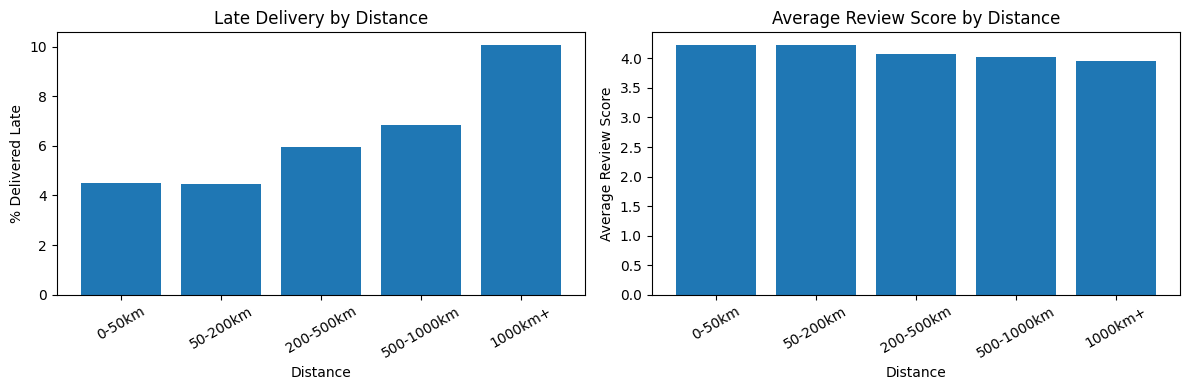

Correlation (distance vs delay): -0.079
Correlation (distance vs review): -0.055


In [182]:
import matplotlib.pyplot as plt

# Divide distance into groups
q1_clean['distance_bucket'] = pd.cut(
    q1_clean['distance_km'],
    bins=[0, 50, 200, 500, 1000, 5000],
    labels=['0-50km', '50-200km', '200-500km', '500-1000km', '1000km+']
)

# Create summary table
summary_q1 = q1_clean.groupby(
    'distance_bucket',
    observed=True
).agg(
    orders=('order_id', 'count'),
    avg_delay_days=('delay_days', 'mean'),
    pct_delivered_late=('delay_days', lambda x: (x > 0).mean() * 100),
    avg_review_score=('review_score', 'mean')
).round(2)

# Create two charts
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Chart 1: Late delivery
ax[0].bar(
    summary_q1.index.astype(str),
    summary_q1['pct_delivered_late']
)
ax[0].set_title('Late Delivery by Distance')
ax[0].set_xlabel('Distance')
ax[0].set_ylabel('% Delivered Late')
ax[0].tick_params(axis='x', rotation=30)

# Chart 2: Review score
ax[1].bar(
    summary_q1.index.astype(str),
    summary_q1['avg_review_score']
)
ax[1].set_title('Average Review Score by Distance')
ax[1].set_xlabel('Distance')
ax[1].set_ylabel('Average Review Score')
ax[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

# Correlation
print(
    'Correlation (distance vs delay):',
    round(q1_clean['distance_km'].corr(q1_clean['delay_days']), 3)
)

print(
    'Correlation (distance vs review):',
    round(q1_clean['distance_km'].corr(q1_clean['review_score']), 3)
)

**Reading the result:** as distance grows from `0-50km` to `1000km+`, the share of orders delivered
late roughly **doubles** (about 4.5% → 10.1%) and the average review score drifts down slightly
(about 4.22 → 3.96). The correlation coefficients are small (~-0.06 to -0.08), so distance is a real
but **modest** factor — plenty of far-away orders still arrive on time and get top ratings. As always,
this is a **correlation, not proof of causation**: other things (courier coverage, regional
infrastructure) likely change together with distance too.


## 5. Question 2 — Which sellers underperform, and how much revenue is at risk?

**Plan:** for every seller, join `order_items` with the average review score of each order, then compute:

- total revenue (sum of `price`)
- average review score
- whether the seller counts as "low-rated" (average score below 3.0)

Then we check what share of total revenue comes from these low-rated sellers.


In [183]:
items_with_review = order_items.merge(review_avg, on='order_id', how='left')

seller_summary = items_with_review.groupby('seller_id').agg(
    n_orders=('order_id', 'nunique'),
    revenue=('price', 'sum'),
    avg_review=('review_score', 'mean')
).reset_index()

seller_summary = seller_summary.dropna(subset=['avg_review'])
print('Sellers analysed:', len(seller_summary))
seller_summary.sort_values('revenue', ascending=False).head()

Sellers analysed: 3090


,seller_id,n_orders,revenue,avg_review
857,4869f7a5dfa277a7dca6462dcf3b52b2,1132,229472.63,4.122822
1013,53243585a1d6dc2643021fd1853d8905,358,222776.05,4.075980
881,4a3ca9315b744ce9f8e9374361493884,1806,200472.92,3.803262
3024,fa1c13f2614d7b5c4749cbc52fecda94,585,194042.03,4.340206
1535,7c67e1448b00f6e969d365cea6b010ab,982,187923.89,3.341445


In [195]:
LOW_RATING_THRESHOLD = 3.0

seller_summary['low_rated'] = seller_summary['avg_review'] < LOW_RATING_THRESHOLD

n_low = seller_summary['low_rated'].sum()

total_revenue = seller_summary['revenue'].sum()

revenue_at_risk = seller_summary.loc[
    seller_summary['low_rated'], 'revenue'
].sum()

pct_low_rated = n_low / len(seller_summary) * 100

pct_at_risk = revenue_at_risk / total_revenue * 100

print('Low-rated sellers:', n_low)
print(f'Percentage of low-rated sellers: {pct_low_rated:.1f}%')
print(f'Total revenue: R$ {total_revenue:,.2f}')
print(f'Revenue at risk: R$ {revenue_at_risk:,.2f}')
print(f'Percentage of revenue at risk: {pct_at_risk:.1f}%')

Low-rated sellers: 343
Percentage of low-rated sellers: 11.1%
Total revenue: R$ 13,583,985.90
Revenue at risk: R$ 412,646.11
Percentage of revenue at risk: 3.0%


In [196]:
# The 10 low-rated sellers who still generate the most revenue -> the ones worth investigating first
top_risk_sellers = (
    seller_summary[seller_summary['low_rated']]
    .sort_values('revenue', ascending=False)
    .head(10)
    .reset_index(drop=True)
)
top_risk_sellers[['seller_id', 'n_orders', 'revenue', 'avg_review']]

,seller_id,n_orders,revenue,avg_review
0,2eb70248d66e0e3ef83659f71b244378,202,42628.61,2.713942
1,b1b3948701c5c72445495bd161b83a4c,18,24699.19,1.722222
2,b37c4c02bda3161a7546a4e6d222d5b2,4,24075.00,1.400000
3,40db9e9aa57f7bb151bcda6b0f9bdbb7,12,23168.00,2.363636
4,8e6d7754bc7e0f22c96d255ebda59eba,85,14497.27,2.973077
5,cf8ab1616079e2793aa29d524df01bb1,9,14391.00,2.000000
6,1ca7077d890b907f89be8c954a02686a,115,13341.57,2.198529
7,c4f7fee5b0db50e87766f5a4d1b1b758,8,11961.83,2.666667
8,54965bbe3e4f07ae045b90b0b8541f52,78,10961.30,2.938272
9,a49928bcdf77c55c6d6e05e09a9b4ca5,98,8816.70,2.952830


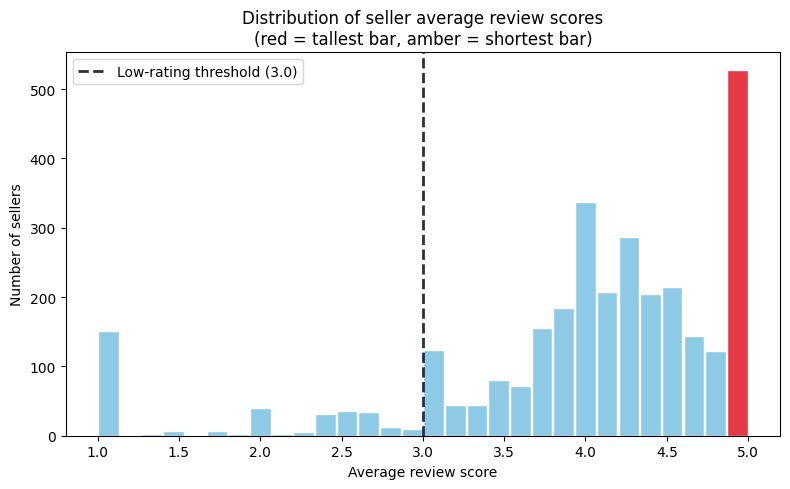

In [197]:
# Histogram: distribution of sellers' average review scores
counts, bin_edges = np.histogram(seller_summary['avg_review'], bins=30)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_edges[1] - bin_edges[0]

max_idx = counts.argmax()
nonzero_counts = counts[counts > 0]
min_idx = np.where(counts == nonzero_counts.min())[0][0]

bar_colors = ['#8ecae6'] * len(counts)   
bar_colors[max_idx] = '#e63946'        
bar_colors[min_idx] = '#ffb703'          

plt.figure(figsize=(8, 5))
plt.bar(bin_centers, counts, width=bin_width * 0.95, color=bar_colors, edgecolor='white')
plt.axvline(LOW_RATING_THRESHOLD, color='#2b2d42', linestyle='--', linewidth=2,
            label=f'Low-rating threshold ({LOW_RATING_THRESHOLD})')
plt.xlabel('Average review score')
plt.ylabel('Number of sellers')
plt.title('Distribution of seller average review scores\n(red = tallest bar, amber = shortest bar)')
plt.legend()
plt.tight_layout()
plt.show()

**Reading the result:** about **11.1% of sellers** have an average review score below 3.0, and they
are responsible for roughly **3.0% of total marketplace revenue** — a meaningful but contained amount.
The histogram shows most sellers cluster in the 4.0-5.0 range (a healthy majority of the marketplace
performs well), with a smaller but clearly visible group sitting to the left of the threshold line.
A handful of these low-rated sellers process hundreds of orders each (see the table above) — they are
the highest-priority sellers for a marketplace's quality team to investigate first, since they carry
both real revenue and real customer-satisfaction risk.


## 6. Question 3 — Do product characteristics affect sales and shipping cost?

**Plan:** for every product, compute how many times it was sold and its average shipping cost
(`freight_value`), then relate that to the product's **weight**, **name length**, **description
length**, and **number of photos**.


In [198]:
product_sales = order_items.groupby('product_id').agg(
    times_sold=('order_id', 'count'),
    avg_price=('price', 'mean'),
    avg_freight=('freight_value', 'mean')
).reset_index()

q3 = product_sales.merge(products, on='product_id', how='left')
q3 = q3.dropna(subset=['product_weight_g', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty'])
print('Products analysed:', len(q3))
q3[['times_sold', 'avg_freight', 'product_weight_g', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty']].describe()

Products analysed: 32340


,times_sold,avg_freight,product_weight_g,product_name_lenght,product_description_lenght,product_photos_qty
count,32340.000000,32340.000000,32340.000000,32340.000000,32340.000000,32340.000000
mean,3.433704,21.235759,2276.956586,48.476592,771.492393,2.188961
std,10.651528,18.123075,4279.291845,10.245699,635.124831,1.736787
min,1.000000,0.010000,0.000000,5.000000,4.000000,1.000000
25%,1.000000,13.610000,300.000000,42.000000,339.000000,1.000000
50%,1.000000,16.725000,700.000000,51.000000,595.000000,1.000000
75%,3.000000,21.890625,1900.000000,57.000000,972.000000,3.000000
max,527.000000,409.680000,40425.000000,76.000000,3992.000000,20.000000


In [199]:
# Correlation matrix: how strongly is each product feature related to sales and shipping cost?
corr_cols = ['times_sold', 'avg_freight', 'product_weight_g',
             'product_name_lenght', 'product_description_lenght', 'product_photos_qty']
q3[corr_cols].corr().round(2)

,times_sold,avg_freight,product_weight_g,product_name_lenght,product_description_lenght,product_photos_qty
times_sold,1.00,-0.02,-0.01,0.01,0.01,0.00
avg_freight,-0.02,1.00,0.66,0.04,0.10,0.05
product_weight_g,-0.01,0.66,1.00,0.04,0.06,0.04
product_name_lenght,0.01,0.04,0.04,1.00,0.10,0.13
product_description_lenght,0.01,0.10,0.06,0.10,1.00,0.11
product_photos_qty,0.00,0.05,0.04,0.13,0.11,1.00


In [200]:
# Weight vs shipping cost, bucketed
q3['weight_bucket'] = pd.cut(
    q3['product_weight_g'], bins=[0, 500, 1000, 3000, 5000, 1_000_000],
    labels=['0-500g', '500g-1kg', '1-3kg', '3-5kg', '5kg+']
)
freight_by_weight = q3.groupby('weight_bucket', observed=True)['avg_freight'].mean().round(2)

# Number of photos vs how many times a product sold
q3['photo_bucket'] = q3['product_photos_qty'].clip(upper=6)  # group 6+ photos together
sales_by_photos = q3.groupby('photo_bucket')['times_sold'].mean().round(2)

print(freight_by_weight)
print()
print(sales_by_photos)

weight_bucket
0-500g      15.53
500g-1kg    17.24
1-3kg       20.43
3-5kg       25.59
5kg+        45.73
Name: avg_freight, dtype: float64

photo_bucket
1.0    3.40
2.0    3.51
3.0    3.21
4.0    3.47
5.0    3.62
6.0    3.77
Name: times_sold, dtype: float64


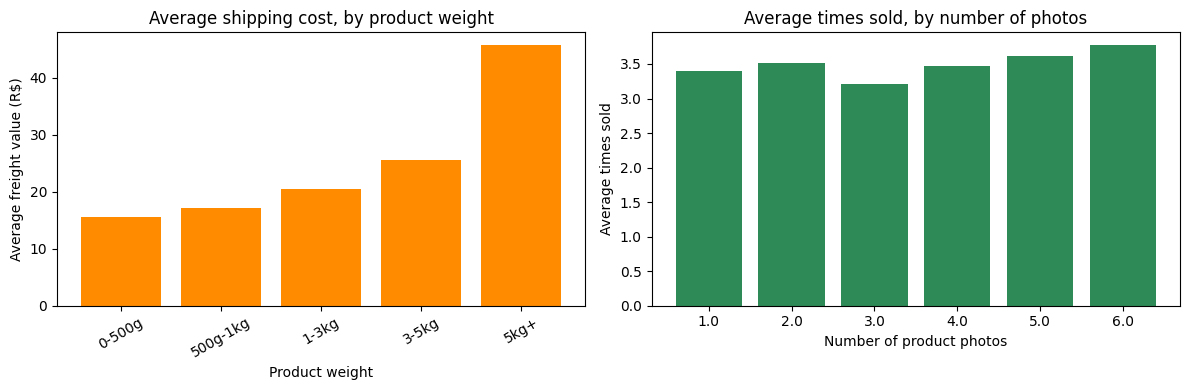

In [201]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(freight_by_weight.index.astype(str), freight_by_weight.values, color='darkorange')
axes[0].set_title('Average shipping cost, by product weight')
axes[0].set_xlabel('Product weight')
axes[0].set_ylabel('Average freight value (R$)')
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(sales_by_photos.index.astype(str), sales_by_photos.values, color='seagreen')
axes[1].set_title('Average times sold, by number of photos')
axes[1].set_xlabel('Number of product photos')
axes[1].set_ylabel('Average times sold')

plt.tight_layout()
plt.show()

**Reading the result:** **weight is the clear driver of shipping cost** — average freight climbs from
about R$15.5 for products under 500g to about R$45.7 for products over 5kg, exactly as expected.
By contrast, **name length, description length, and number of photos barely move sales** at all
(correlations near 0, and the "average times sold by photo count" bars are almost flat around 3.2–3.8).
In this dataset, **listing quality (text/photos) is not what drives demand** — price, category, and
brand/product-fit likely matter far more than how the listing is written.


## 7. Question 4 — Who are the repeat buyers, and how do they behave?

**Plan:** remember that `customer_id` is **not** a real person — the same person gets a new
`customer_id` every time they order. We must group by `customer_unique_id` to count how many times a
real person actually bought something, then compare repeat buyers vs one-time buyers on **payment
method** and **product category**.


In [202]:
# Attach the real person's id to every order
orders_cust = orders.merge(customers[['customer_id', 'customer_unique_id']], on='customer_id', how='left')

# Count distinct orders per real person
order_counts = orders_cust.groupby('customer_unique_id')['order_id'].nunique().reset_index(name='n_orders')
print('Total unique customers (real people):', len(order_counts))

repeat_buyers = order_counts[order_counts['n_orders'] > 1]
pct_repeat = len(repeat_buyers) / len(order_counts) * 100
print(f'Repeat buyers (2+ orders): {len(repeat_buyers):,} ({pct_repeat:.2f}% of all customers)')

order_counts['n_orders'].value_counts().sort_index().head(6)

Total unique customers (real people): 96096
Repeat buyers (2+ orders): 2,997 (3.12% of all customers)


n_orders
1    93099
2     2745
3      203
4       30
5        8
6        6
Name: count, dtype: int64

In [203]:
# Flag every order as belonging to a repeat buyer or a one-time buyer
orders_cust = orders_cust.merge(order_counts, on='customer_unique_id', how='left')
orders_cust['is_repeat'] = orders_cust['n_orders'] > 1

# Payment method mix: repeat buyers vs one-time buyers
payments_flagged = order_payments.merge(orders_cust[['order_id', 'is_repeat']], on='order_id', how='left').dropna(subset=['is_repeat'])
payment_mix = (
    payments_flagged.groupby('is_repeat')['payment_type']
    .value_counts(normalize=True)
    .mul(100).round(1)
    .unstack()
)
payment_mix.index = payment_mix.index.map({True: 'Repeat buyers', False: 'One-time buyers'})
payment_mix

payment_type,boleto,credit_card,debit_card,not_defined,voucher
is_repeat,,,,,
One-time buyers,19.1,74.0,1.5,0.0,5.4
Repeat buyers,17.6,72.7,1.2,0.0,8.5


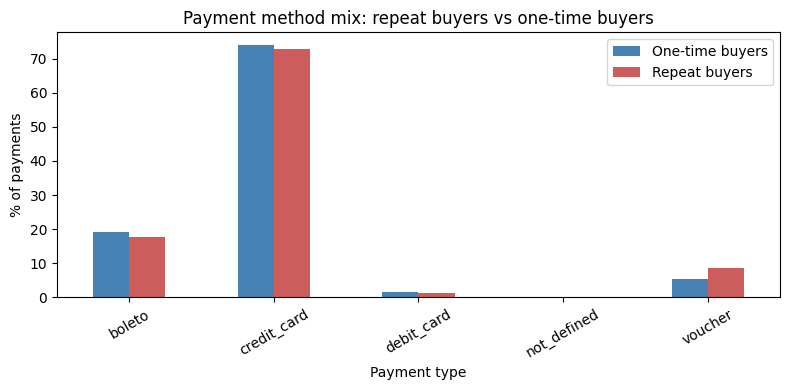

In [204]:
# Bar chart comparing payment method mix
payment_mix.T.plot(kind='bar', figsize=(8, 4), color=['steelblue', 'indianred'])
plt.title('Payment method mix: repeat buyers vs one-time buyers')
plt.ylabel('% of payments')
plt.xlabel('Payment type')
plt.xticks(rotation=30)
plt.legend(title='')
plt.tight_layout()
plt.show()

In [205]:
# Product category preference: repeat buyers vs one-time buyers (top 5 each, English names)
items_cat = order_items.merge(products[['product_id', 'product_category_name']], on='product_id', how='left')
items_cat = items_cat.merge(category_translation, on='product_category_name', how='left')
items_cat = items_cat.merge(orders_cust[['order_id', 'is_repeat']], on='order_id', how='left').dropna(subset=['is_repeat'])

top_categories_repeat = (
    items_cat[items_cat['is_repeat']]['product_category_name_english']
    .value_counts(normalize=True).mul(100).round(1).head(5)
)
top_categories_onetime = (
    items_cat[~items_cat['is_repeat']]['product_category_name_english']
    .value_counts(normalize=True).mul(100).round(1).head(5)
)

print('--- Repeat buyers: top 5 categories (%) ---')
print(top_categories_repeat)
print()
print('--- One-time buyers: top 5 categories (%) ---')
print(top_categories_onetime)

--- Repeat buyers: top 5 categories (%) ---
product_category_name_english
bed_bath_table           14.9
furniture_decor          11.0
sports_leisure            9.2
health_beauty             7.6
computers_accessories     7.4
Name: proportion, dtype: float64

--- One-time buyers: top 5 categories (%) ---
product_category_name_english
bed_bath_table           9.7
health_beauty            8.8
sports_leisure           7.7
furniture_decor          7.3
computers_accessories    7.0
Name: proportion, dtype: float64


**Reading the result:** only about **3.1% of customers** come back for a second order — this
marketplace runs mostly on **one-time purchases**, which is common for a multi-category marketplace
(vs. a subscription or grocery business). Payment behavior is very similar between the two groups
(around 73-74% credit card either way), but repeat buyers use **vouchers noticeably more** (8.5% vs
5.4%) — consistent with vouchers being a loyalty/retention tool. Category preferences are close between
both groups (`bed_bath_table`, `health_beauty`, `sports_leisure` dominate either way), so **repurchase
is not concentrated in one niche category** — it is more about the customer than the product type.


## 8. Conclusion

Based on the analysis above, here is what the data tells us (the answers to our original questions):

1. **Distance vs. delivery & satisfaction.** Distance does matter, but modestly: the share of late
   deliveries roughly doubles from the closest bucket (0-50km, ~4.5% late) to the farthest
   (1000km+, ~10.1% late), and average review score drifts from ~4.22 down to ~3.96. The correlation
   is weak (~-0.06 to -0.08), so distance is a real but secondary factor in customer experience.
2. **Seller performance & revenue at risk.** About **11.1%** of sellers have an average review score
   below 3.0, and together they account for roughly **3.0%** of total marketplace revenue
   (~R$413K). A handful of these low-rated sellers process hundreds of orders each — they are the
   highest-priority sellers for a marketplace's quality team to investigate.
3. **Product characteristics vs. sales & shipping.** **Weight strongly drives shipping cost**
   (avg freight triples from ~R$15.5 for light products to ~R$45.7 for products over 5kg), but
   **name length, description length, and photo count have almost no relationship with sales**
   (correlations near 0). Listing "richness" alone does not sell more — other factors (price,
   category, demand) dominate.
4. **Repeat buyers.** Only **~3.1%** of customers place a second order using the correct
   `customer_unique_id` key (not `customer_id`, which would wrongly count every order as a new
   customer). Repeat buyers pay similarly to one-time buyers but lean more on **vouchers** (8.5% vs
   5.4%), and shop across roughly the same top categories as everyone else.

### Key takeaways for this project

- The dataset is **relational, not flat** — every question here needed at least 2-4 joins across
  `orders`, `order_items`, `order_reviews`, `products`, `sellers`, `customers`, and `geolocation`.
- **Aggregate before joining** on a many-to-many key (we had to collapse `geolocation` from ~1M rows
  to ~19K zip centroids before joining it to customers/sellers).
- Use **`customer_unique_id`**, not `customer_id`, whenever the question is about a real person
  rather than a single order.
- Always report **correlation, not causation** — distance and review score move together only a
  little, and other unmeasured factors likely explain more of the story.
